/tmp/ipykernel_4922/2640647954.py:13: RuntimeWarning: overflow encountered in square
  r2 = x1**2 + x2**2
/tmp/ipykernel_4922/2640647954.py:15: RuntimeWarning: invalid value encountered in scalar add
  -x1 + x2 + x1*r2,
/tmp/ipykernel_4922/2640647954.py:16: RuntimeWarning: invalid value encountered in subtract
  -x1 - x2 + x2*r2
/tmp/ipykernel_4922/2640647954.py:15: RuntimeWarning: overflow encountered in multiply
  -x1 + x2 + x1*r2,
/tmp/ipykernel_4922/2640647954.py:16: RuntimeWarning: overflow encountered in multiply
  -x1 - x2 + x2*r2


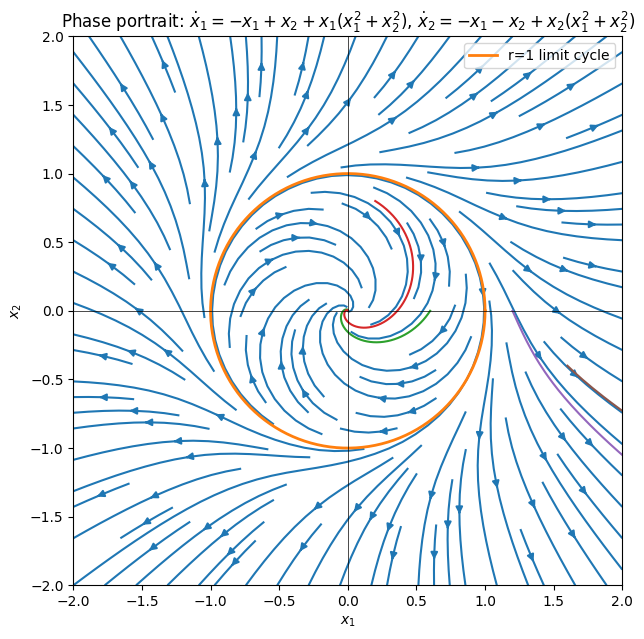

In [1]:
# -*- coding: utf-8 -*-
# Phase portrait for:
# x1_dot = -x1 + x2 + x1*(x1**2 + x2**2)
# x2_dot = -x1 - x2 + x2*(x1**2 + x2**2)

import numpy as np
import matplotlib.pyplot as plt

# --------- 系统函数 ---------
def f(x):
    """ 右端项 f(x) """
    x1, x2 = x[..., 0], x[..., 1]
    r2 = x1**2 + x2**2
    return np.stack([
        -x1 + x2 + x1*r2,
        -x1 - x2 + x2*r2
    ], axis=-1)

# --------- 简单 RK4 积分器 ---------
def rk4_step(x, h):
    k1 = f(x)
    k2 = f(x + 0.5*h*k1)
    k3 = f(x + 0.5*h*k2)
    k4 = f(x + h*k3)
    return x + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def simulate(x0, T=8.0, h=0.01):
    n = int(T/h)
    xs = np.zeros((n+1, 2))
    xs[0] = x0
    for k in range(n):
        xs[k+1] = rk4_step(xs[k], h)
    t = np.linspace(0, T, n+1)
    return t, xs

# --------- 画向量场（流线） ---------
x1 = np.linspace(-2, 2, 25)
x2 = np.linspace(-2, 2, 25)
X1, X2 = np.meshgrid(x1, x2)
U = -X1 + X2 + X1*(X1**2 + X2**2)
V = -X1 - X2 + X2*(X1**2 + X2**2)

plt.figure(figsize=(6.5, 6.5))
plt.streamplot(X1, X2, U, V, density=1.2, arrowsize=1)

# --------- 画单位圆（极限环） ---------
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), linewidth=2, label='r=1 limit cycle')

# --------- 几组初值轨迹 ---------
inits = [
    np.array([0.6, 0.0]),    # 圆内：向内螺旋
    np.array([0.2, 0.8]),
    np.array([1.2, 0.0]),    # 圆外：向外螺旋
    np.array([1.6,-0.4])
]
for x0 in inits:
    t, traj = simulate(x0, T=8.0, h=0.01)
    plt.plot(traj[:,0], traj[:,1], lw=1.5)

# --------- 图形修饰 ---------
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-2, 2); plt.ylim(-2, 2)
plt.xlabel(r"$x_1$"); plt.ylabel(r"$x_2$")
plt.title(r"Phase portrait: $\dot x_1=-x_1+x_2+x_1(x_1^2+x_2^2)$, "
          r"$\dot x_2=-x_1-x_2+x_2(x_1^2+x_2^2)$")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


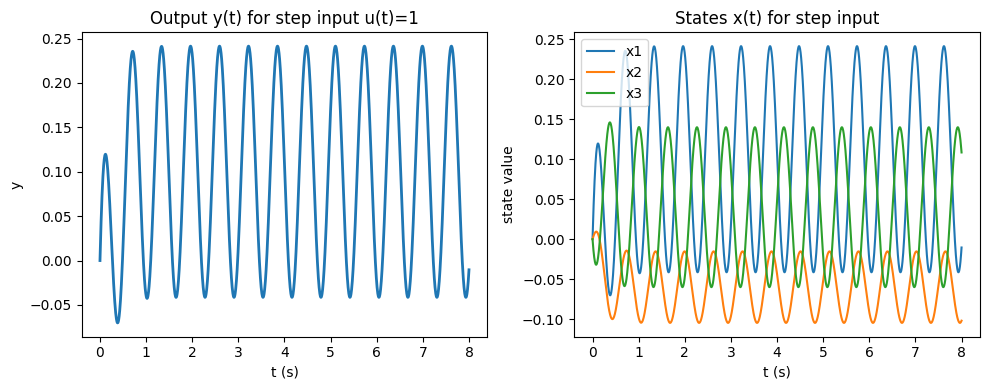

In [2]:
# Problem 7 (ii): step response & state trajectories
# pip install numpy scipy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import StateSpace, lsim

# ---------- 系统矩阵 ----------
A = np.array([[-25., -45., -55.],
              [ -5., -15., -15.],
              [ 15.,  35.,  35.]])
B = np.array([[ 2.0],
              [ 0.2],
              [-0.8]])
C = np.array([[1., 0., 0.]])   # y = x1
D = np.array([[0.]])

sys = StateSpace(A, B, C, D)

# ---------- 阶跃输入 u(t) = 1(t) ----------
T = np.linspace(0, 8, 2000)     # 仿真时域
U = np.ones_like(T)             # 阶跃

# lsim 会返回输出 y(t) 和状态 x(t)
t, y, x = lsim(sys, U=U, T=T, X0=np.zeros(3))

# ---------- 画图 ----------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t, y.squeeze(), linewidth=2)
plt.title("Output y(t) for step input u(t)=1")
plt.xlabel("t (s)")
plt.ylabel("y")

plt.subplot(1,2,2)
plt.plot(t, x[:,0], label="x1")
plt.plot(t, x[:,1], label="x2")
plt.plot(t, x[:,2], label="x3")
plt.title("States x(t) for step input")
plt.xlabel("t (s)")
plt.ylabel("state value")
plt.legend()
plt.tight_layout()
plt.show()
